In [11]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "src")
import numpy as np
import pandas as pd
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import data
from moq import strategies


prices = pd.read_parquet(DATA / "processed" / "precos.parquet")
cdi = pd.read_parquet( DATA / "processed" / "cdi.parquet")["cdi"]
rets = prices.pct_change(fill_method=None).fillna(0.0)
prices.shape, cdi.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((3653, 23), (3653,))

In [13]:
@strategies.lagged()
def pesos_iguais(prices):
    return pd.DataFrame(1.0 / prices.shape[1], index=prices.index, columns=prices.columns)

w = pesos_iguais(prices)
print(w.iloc[0].sum())
print(w.iloc[1].sum())
print(w.abs().sum(axis=1).max())

0.0
0.9999999999999998
0.9999999999999998


In [15]:
# @strategies.lagged()
# def alavancada(prices):
#     return pd.DataFrame(2.0 / prices.shape[1], index=prices.index, columns=prices.columns)

# alavancada(prices)

In [16]:
lookback, skip = 252, 21
mom = prices.shift(skip) / prices.shift(lookback) - 1.0
mom.tail(3).round(3)

,ABEV3,B3SA3,BBAS3,BBDC4,CMIG4,CSAN3,ENEV3,EQTL3,GGBR4,ITSA4,...,PETR4,PRIO3,RADL3,RENT3,SBSP3,SUZB3,TOTS3,VALE3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-10,0.297,0.126,-0.067,0.059,0.044,-0.551,0.617,0.020,0.424,0.266,...,0.449,0.621,0.099,-0.043,0.100,-0.206,-0.277,0.393,-0.050,0.306
2026-09-11,0.295,0.142,-0.072,0.061,0.042,-0.570,0.590,0.016,0.473,0.253,...,0.436,0.616,0.102,-0.043,0.104,-0.179,-0.306,0.405,-0.045,0.328
2026-09-14,0.281,0.199,-0.129,0.066,0.040,-0.540,0.590,0.003,0.491,0.257,...,0.440,0.593,0.106,-0.040,0.037,-0.183,-0.286,0.384,-0.058,0.341


In [17]:
rank = mom.rank(axis=1, pct=True)
rank.loc["2023-06-01"].sort_values(ascending=False).head()

WEGE3    1.000000
RADL3    0.956522
BBAS3    0.913043
PRIO3    0.869565
CMIG4    0.826087
Name: 2023-06-01 00:00:00, dtype: float64

In [18]:
top = 0.2
sel = (rank >= 1.0 - top).astype(float).where(mom.notna(), 0.0)
sel.sum(axis=1).tail()

Date
2026-09-08    5.0
2026-09-09    5.0
2026-09-10    5.0
2026-09-11    5.0
2026-09-14    5.0
dtype: float64

In [19]:
sel = strategies._normalize_rows(sel)
sel.loc["2023-06-01"][sel.loc["2023-06-01"] > 0]

BBAS3    0.2
CMIG4    0.2
PRIO3    0.2
RADL3    0.2
WEGE3    0.2
Name: 2023-06-01 00:00:00, dtype: float64

In [22]:
sel_m = sel.resample("ME").last().reindex(prices.index, method="ffill").fillna(0.0)
(sel_m.diff().abs().sum(axis=1) > 0).sum()

np.int64(126)

<Axes: title={'center': 'Exposição bruta do momentum'}, xlabel='Date'>

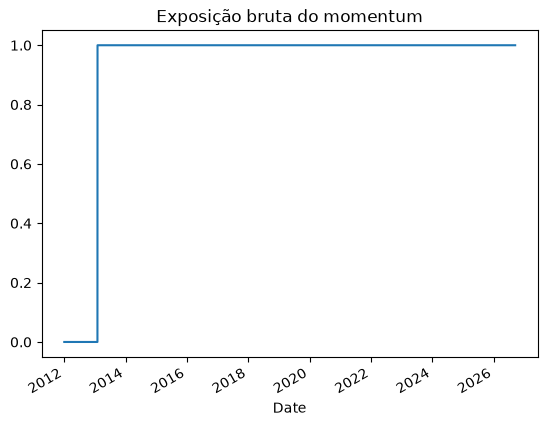

In [23]:
w_mom = strategies.momentum(prices)
w_mom.abs().sum(axis=1).plot(title="Exposição bruta do momentum")

<Axes: title={'center': 'Patrimônio (provisório, sem custos)'}, xlabel='Date'>

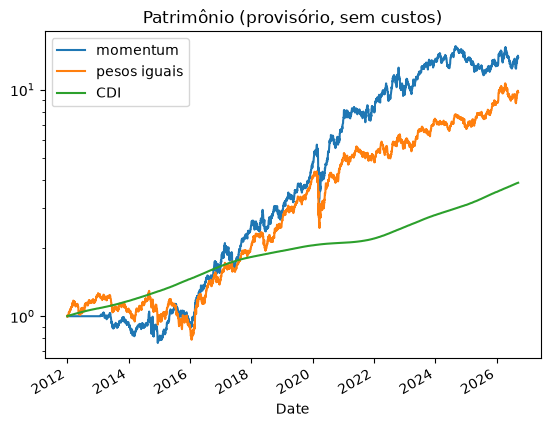

In [24]:
def retorno_bruto(w, rets):
    """Provisório. Sem custo, sem CDI no caixa. Só para olhar."""
    return (w * rets).sum(axis=1)

r_mom = retorno_bruto(w_mom, rets)
r_ew = retorno_bruto(pesos_iguais(prices), rets)

pd.DataFrame({"momentum": (1 + r_mom).cumprod(),
              "pesos iguais": (1 + r_ew).cumprod(),
              "CDI": (1 + cdi).cumprod()}).plot(logy=True, title="Patrimônio (provisório, sem custos)")

qual a diferença entre loc e iloc?

In [25]:
short, long = 5, 60
r5 = prices.pct_change(short, fill_method=None)
z = (r5 - r5.rolling(long).mean()) / r5.rolling(long).std(ddof=1)
z.loc["2020-3-16"].sort_values().head()

ABEV3   -3.746891
WEGE3   -3.472206
LREN3   -3.447305
RENT3   -3.295309
RADL3   -3.195278
Name: 2020-03-16 00:00:00, dtype: float64

<Axes: title={'center': 'Quantos ativos com sinal por dia'}, xlabel='Date'>

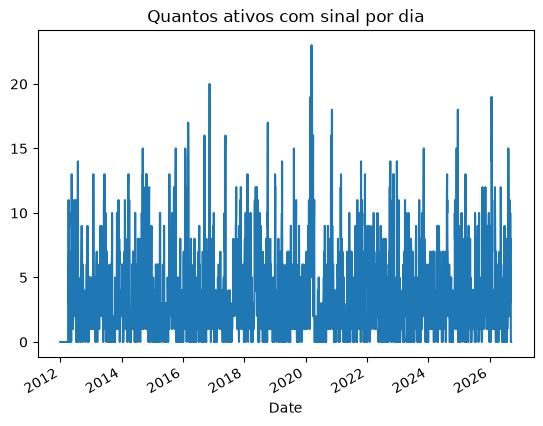

In [26]:
threshold = 1.5
signal = (-z).where(z.abs() > threshold, 0.0).fillna(0.0)
(signal != 0).sum(axis=1).plot(title="Quantos ativos com sinal por dia")

In [27]:
def turnover_anual(w):
    return w.diff().abs().sum(axis=1).mean() * 252

print("momentum:", round(turnover_anual(w_mom), 1))
print("reversão:", round(turnover_anual(strategies.mean_reversion(prices)), 1))

momentum: 5.3
reversão: 254.5


Ao escolhermos dois ativos que deveriam andar juntos, vemos que eles sobem e descem juntos, mas a distância entre as linhas varia. Essa distância é o spread, e a estratégia aposta que ela volta ao normal.

<Axes: title={'center': 'Log-preços, base 0'}, xlabel='Date'>

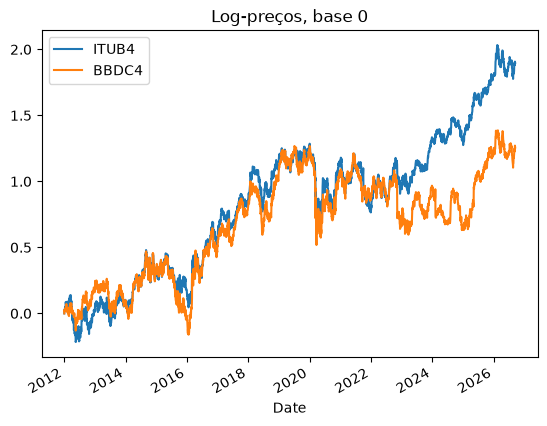

In [28]:
a, b = "ITUB4", "BBDC4"
(np.log(prices[[a,b]]) - np.log(prices[[a,b]]).iloc[0]).plot(title="Log-preços, base 0")

In [29]:
from statsmodels.tsa.stattools import coint

treino = prices["2012":"2017"]
pval = coint(np.log(treino[a]), np.log(treino[b]))[1]
print(f"p-valor {a}/{b}: {pval:.3f}")

p-valor ITUB4/BBDC4: 0.426


In [30]:
candidatos = [("PETR3", "PETR4"), ("ITUB4", "BBC4"), ("ITSA4", "ITUB4"), ("CMIG4", "SBSP3")]
for x, y in candidatos:
    if x in treino and y in treino:
        p = coint(np.log(treino[x]), np.log(treino[y]))[1]
        print(f"{x}/{y}: p = {p:.3f} {'✔' if p < 0.05 else ''}")

PETR3/PETR4: p = 0.274 
ITSA4/ITUB4: p = 0.085 
CMIG4/SBSP3: p = 0.571 


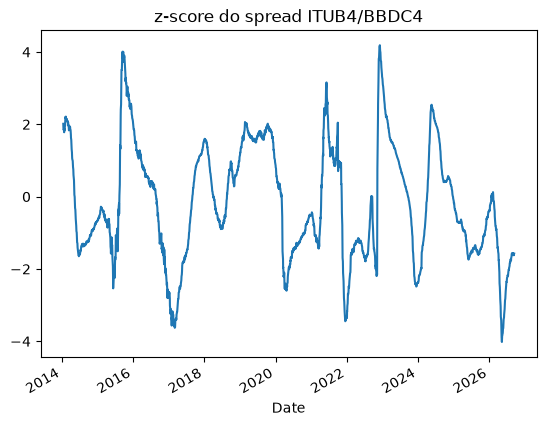

In [31]:
window = 252
la, lb = np.log(prices[a]), np.log(prices[b])
beta = la.rolling(window).cov(lb) /lb.rolling(window).var(ddof=1)
spread = la - beta * lb
z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std(ddof=1)
z.plot(title=f"z-score do spread {a}/{b}");

Máquina de Estados

<Axes: title={'center': 'posição (+1 / 0 / -1)'}, xlabel='Date'>

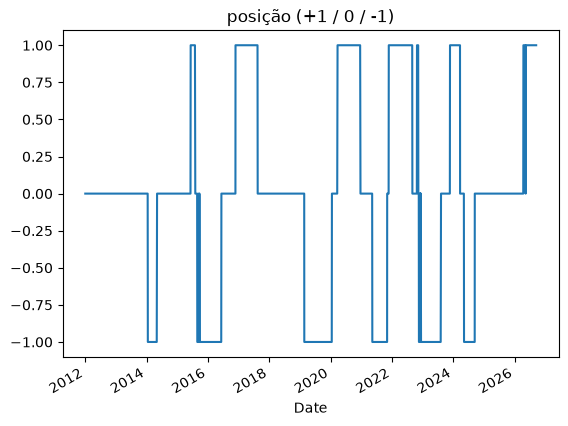

In [ ]:
entry, exit, stop = 2.0, 0.5, 4.0
state, pos, zv = 0, np.zeros(len(z)), z.to_numpy()
for t in range(len(zv)):
    if np.isnan(zv[t]):
        state = 0
    elif state == 0:                            #fora do mercado
        if zv[t] > entry: state = -1            # spread alto: vende a, compra b
        elif zv[t] < -entry: state = 1          #spread baixo: compra a, vende b
    else:
        if abs(zv[t]) < exit or abs(zv[t]) > stop:
            state = 0                           # convergiu (saída) ou rompeu (stop)
    pos[t] = state

pd.Series(pos, index=z.index).plot(title="posição (+1 / 0 / -1)")


In [34]:
rng = np.random.default_rng(1)
y_1y = pd.Series(0.10 + np.cumsum(rng.normal(0, 0.0015, len(prices))), index=prices.index).clip(0.02, 0.25)

In [35]:
y = y_1y.reindex(cdi.index).ffill()
dur = 1.0 / (1.0 + y.shift(1))
r_bond = (y.shift(1) / 252.0 - dur * y.diff()).fillna(0.0)
r_bond.describe()

count    3653.000000
mean        0.000235
std         0.001264
min        -0.004792
25%        -0.000426
50%         0.000079
75%         0.000961
max         0.005273
dtype: float64

In [37]:
cdi_anual = (1 + cdi) ** 252 - 1
slope = y - cdi_anual
thr = slope.rolling(252).mean() + 1.0 * slope.rolling(252).std(ddof=1)
sig = (slope > thr).astype(float).fillna(0.0)
print(sig.mean())

0.2499315630988229
